In [1]:
import pickle
import pandas as pd

In [2]:
with open('data/results_all.pickle', 'rb') as f:
    results_all = pickle.load(f)

In [3]:
print(results_all[0].keys())

dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'non_serializable'])


In [4]:
ser_res = [{k: v for k, v in r.items() if k != 'non_serializable'} for r in results_all]

In [5]:
print(len(ser_res))
print(ser_res[0].keys())

4380
dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a'])


In [6]:
df = pd.DataFrame(ser_res)

In [7]:
df.head(10)

,path,guidance_arch,contra,num_guidance_steps,guidance_model,graph,bilstm,token,graph_a,token_a,adapter_a
0,MIDIs/no_guide/gen_jigs85.mid_no,LoRA,True,16,no,0.060721,-0.078383,-0.045905,0.176050,-0.005411,0.055894
1,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,graph,0.302009,-0.028569,-0.067654,0.346710,0.150544,0.153603
2,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,bilstm,0.117718,0.092886,-0.051932,0.183256,0.162621,0.049517
3,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,token,0.208426,-0.043200,0.208649,0.294704,0.567108,0.333193
4,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,adapter,0.208961,0.065243,0.252351,0.421750,0.717896,0.425914
5,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,no,0.067137,-0.089206,-0.100497,0.191056,0.043039,0.114770
6,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,graph,0.125491,-0.056922,-0.056559,0.095475,-0.006105,0.038125
7,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,bilstm,0.210896,-0.074341,-0.095993,0.244454,-0.061286,0.071077
8,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,token,0.655322,0.119329,0.139194,0.615641,0.454184,0.382332
9,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,adapter,0.603086,0.197972,0.290312,0.623144,0.761074,0.527847


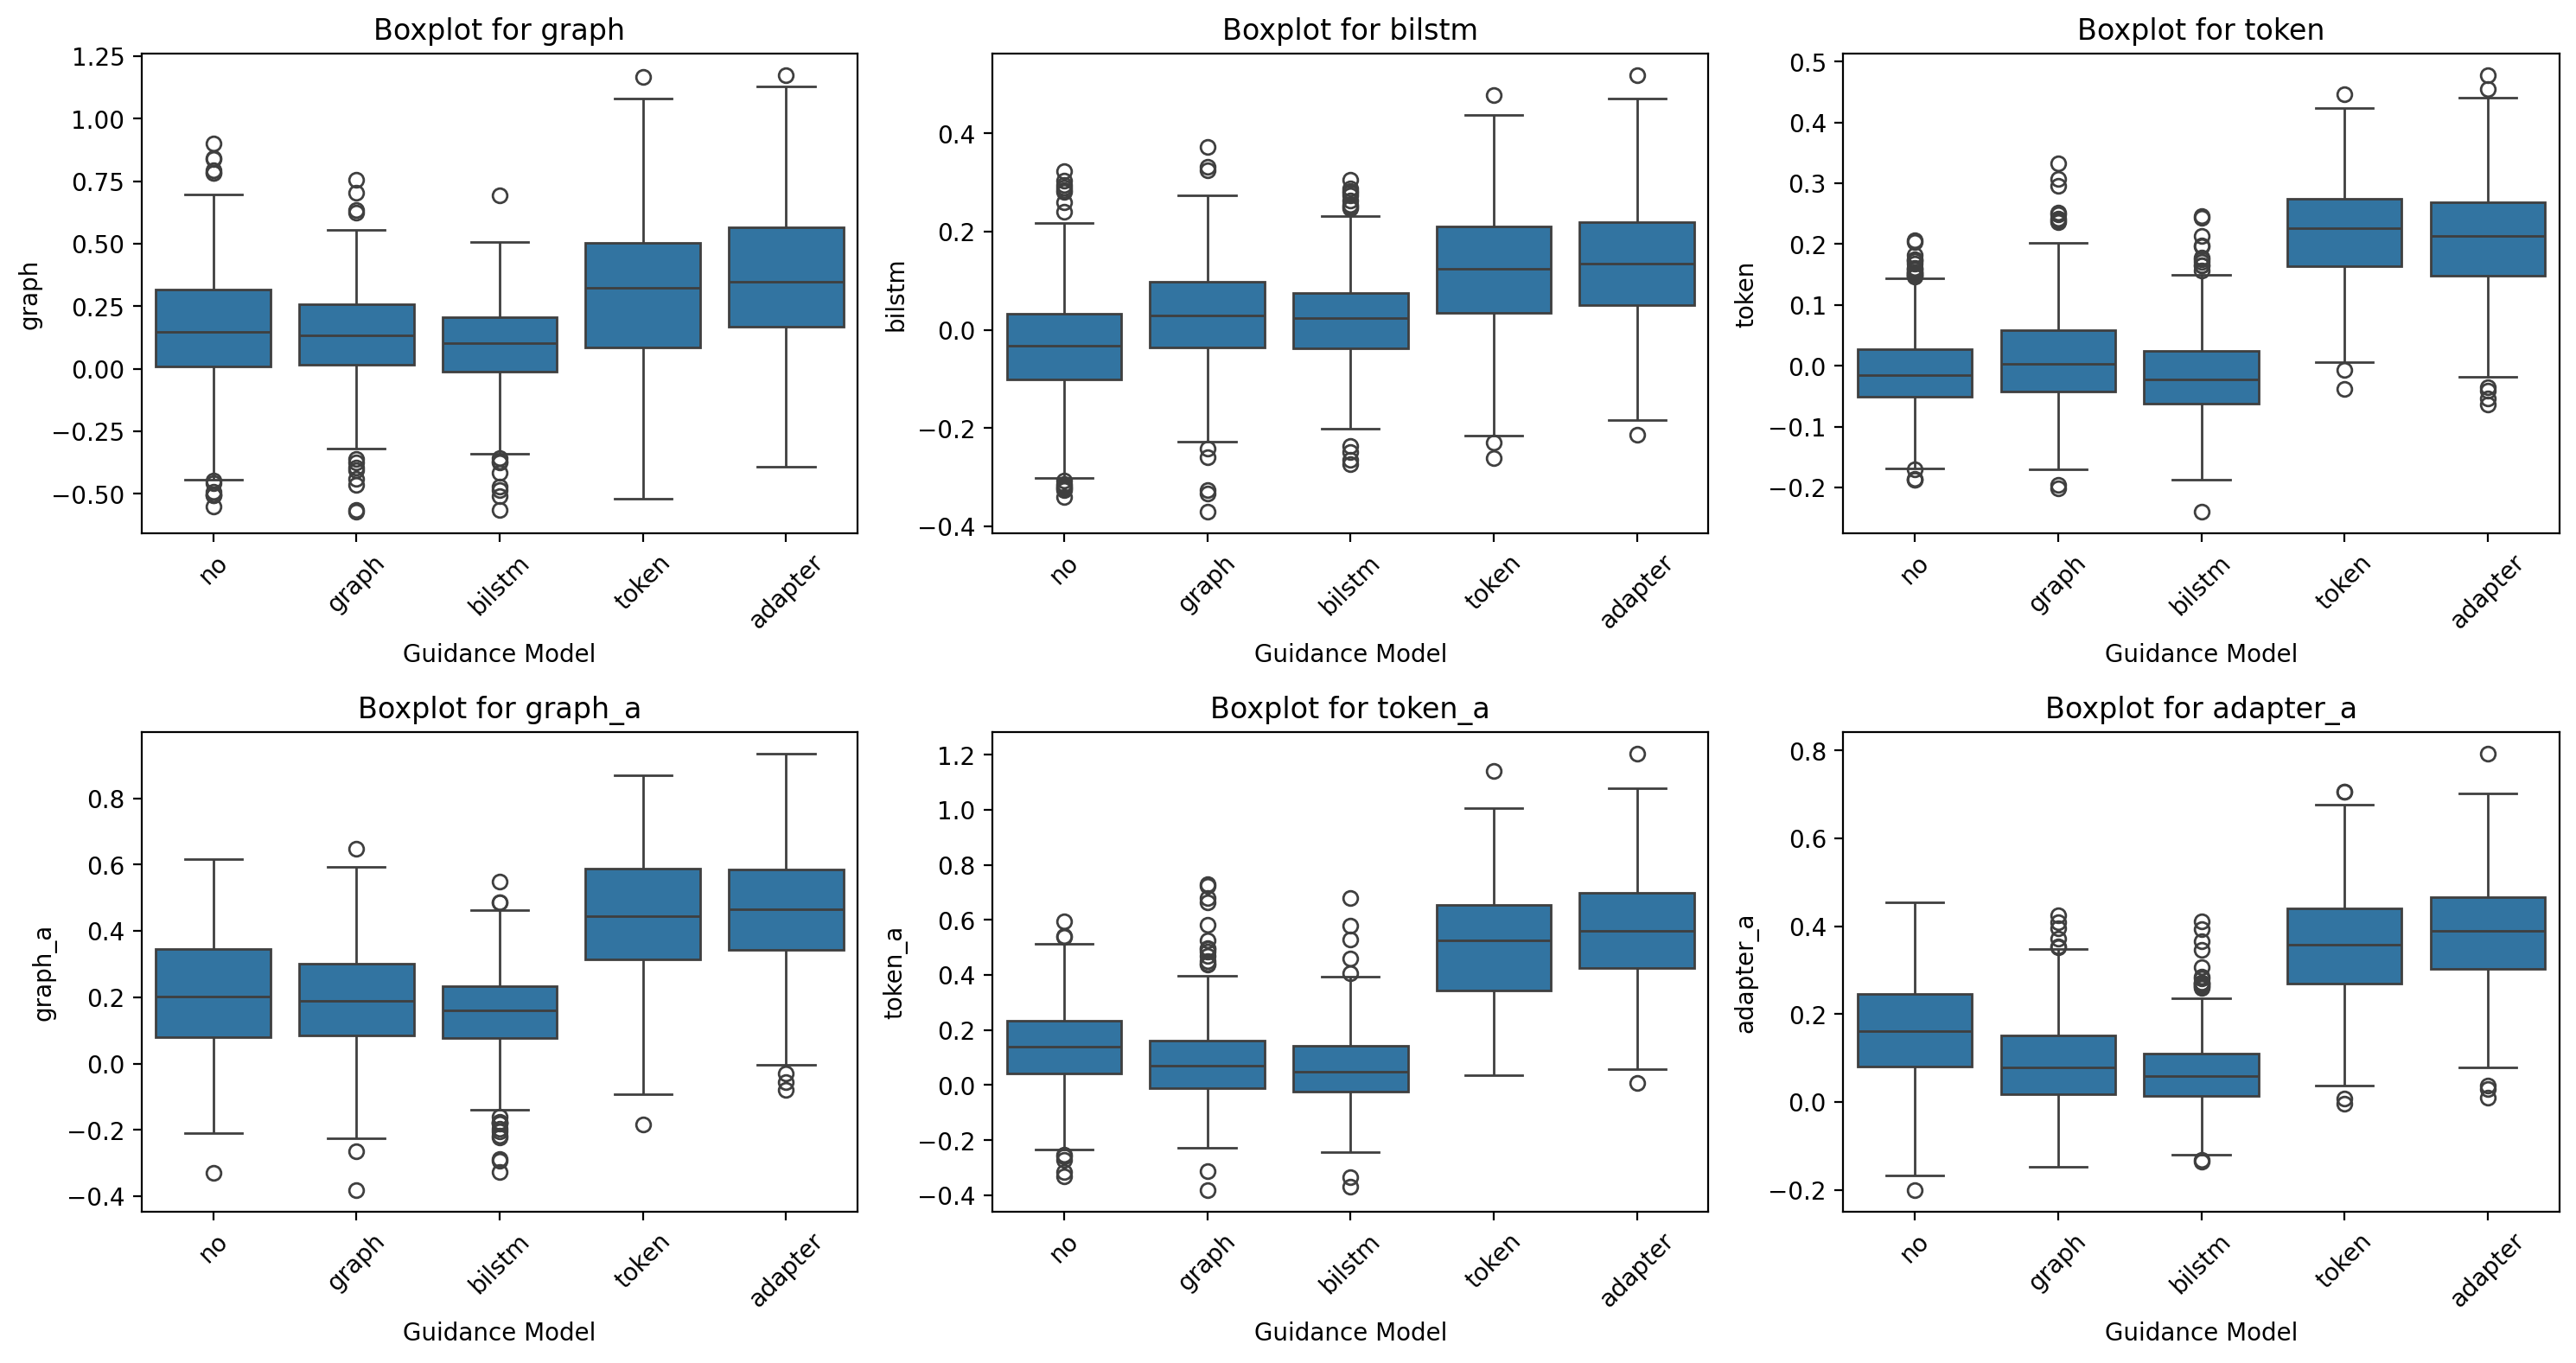

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
df_contra = df[df['contra'] == True].copy()

metrics = [
    col for col in df_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [9]:
from scipy import stats

# Use the same filtered subset for the statistical comparison.
df_filtered = df[df['contra'] == True].copy()
metrics = [
    col for col in df_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_filtered[df_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_filtered[df_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic   p_value  significant
0      graph      87466.0  0.023935        False
1     bilstm      89907.5  0.108246        False
2      token     103064.5  0.056472        False
3    graph_a      92671.0  0.385343        False
4    token_a      83823.5  0.001234         True
5  adapter_a      84764.0  0.002885         True


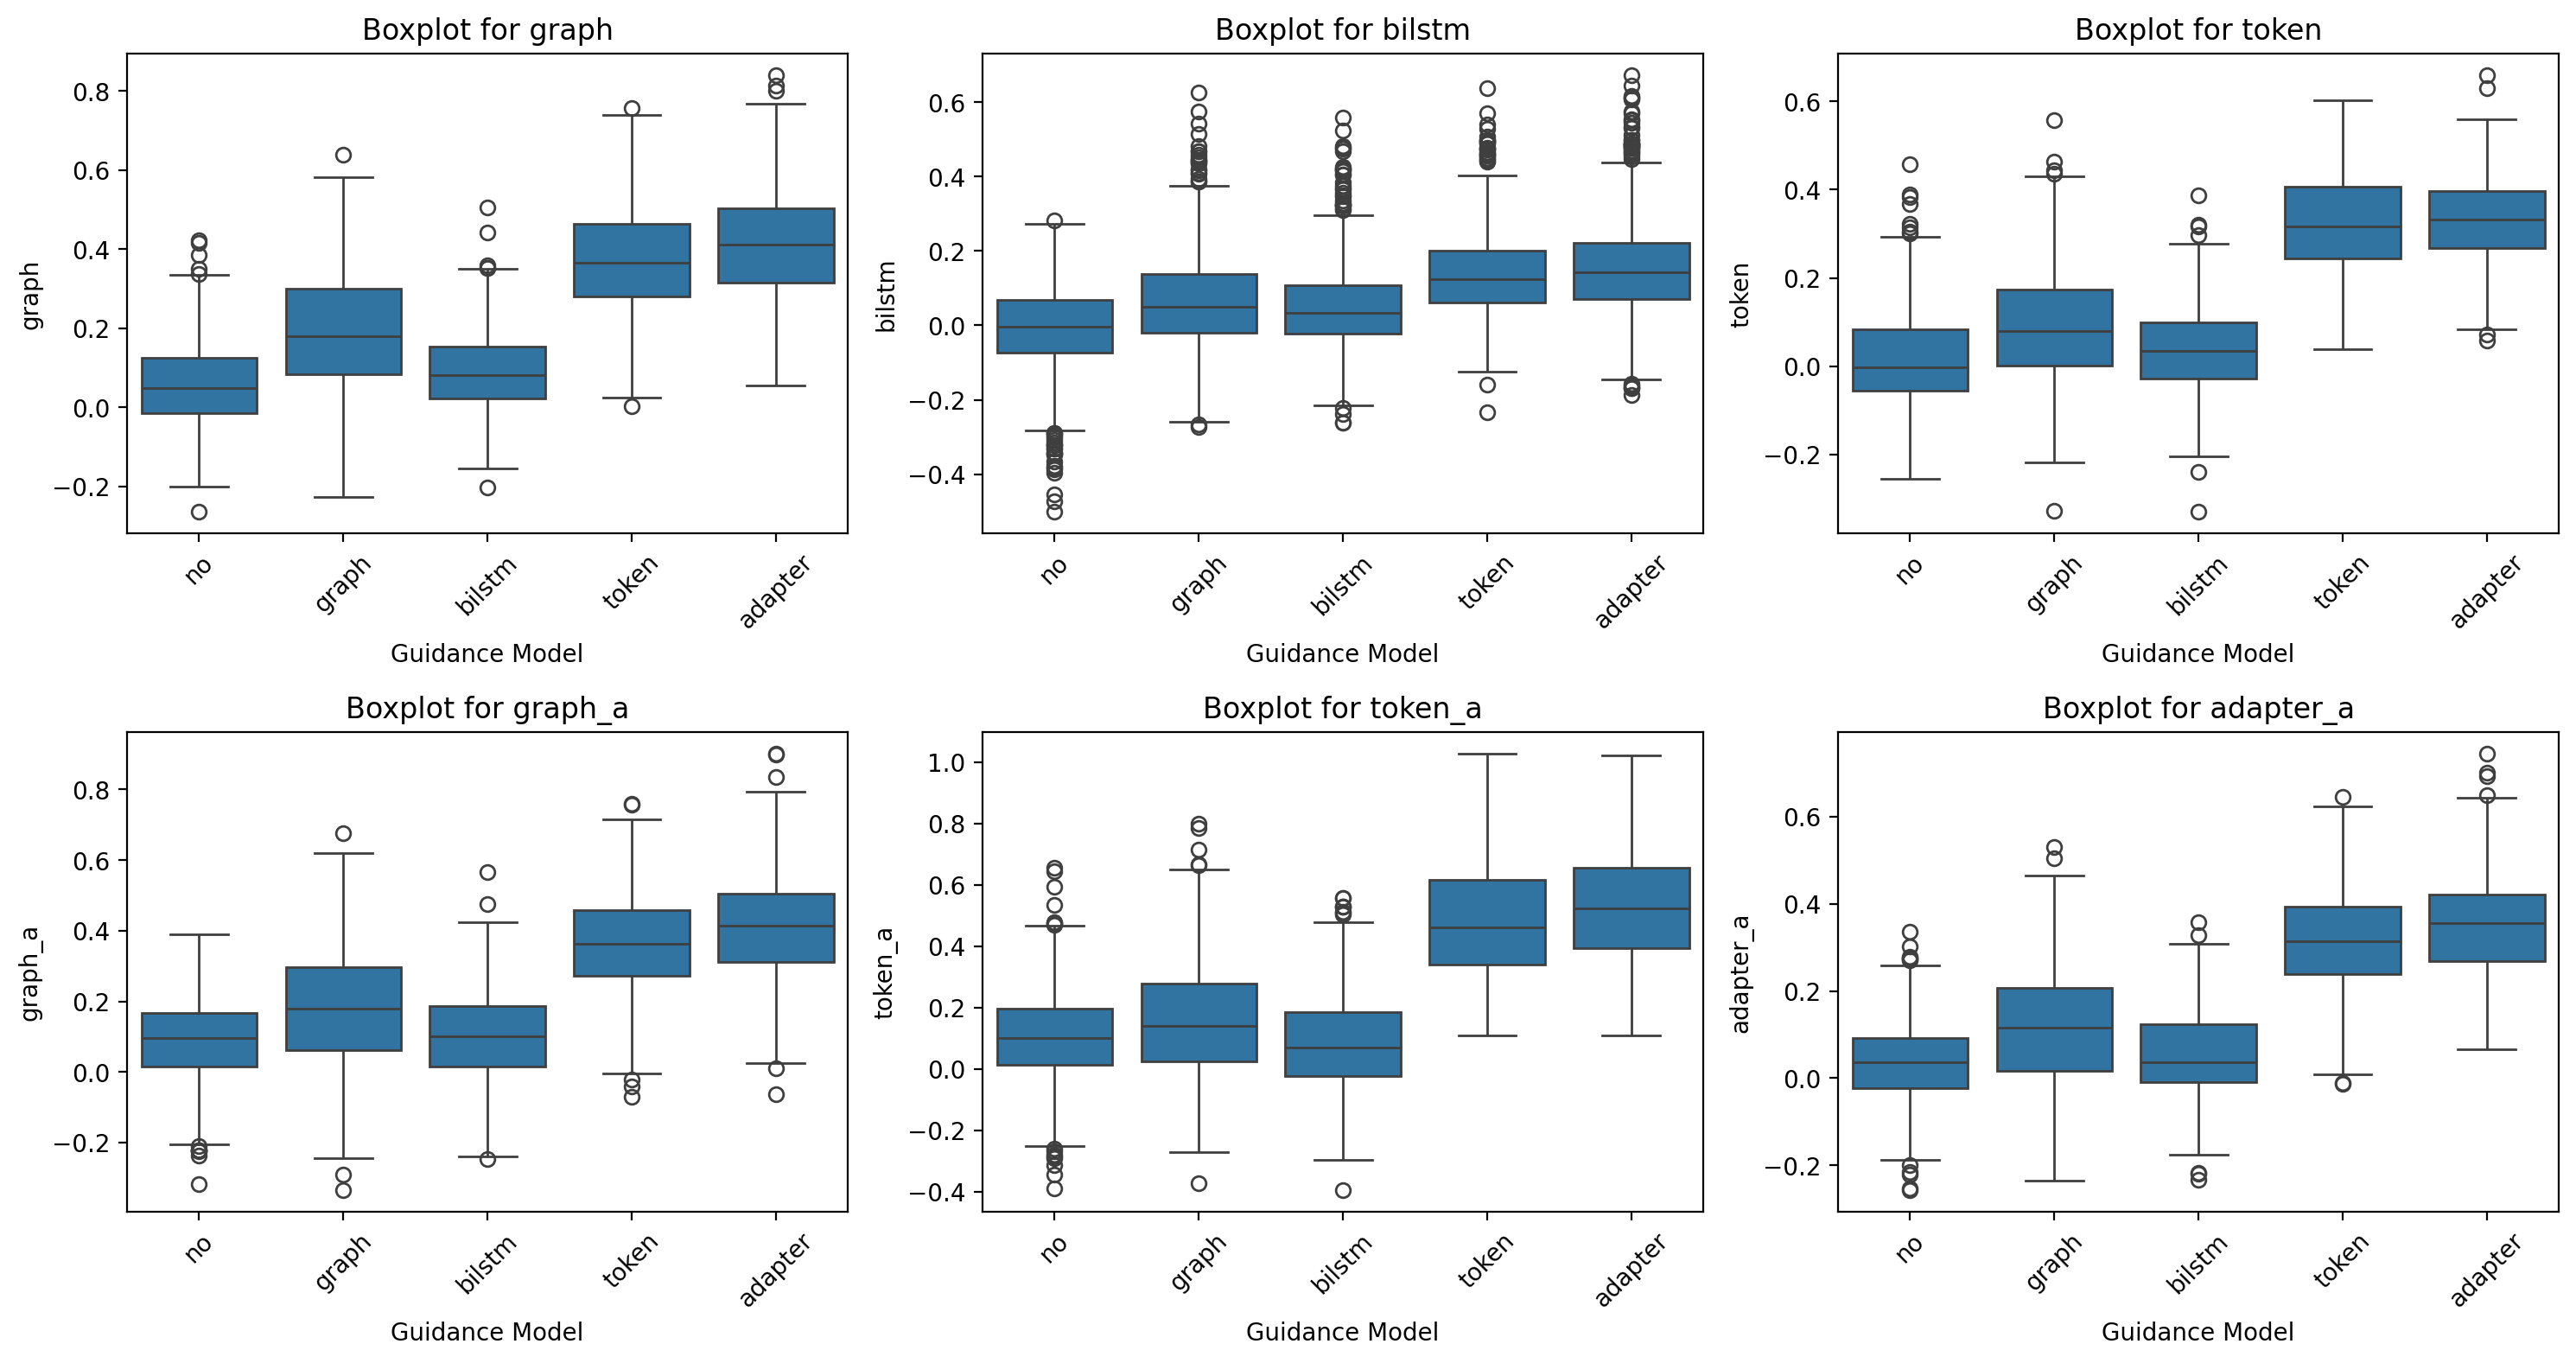

In [11]:
# Restrict the analysis to rows where contrastive training was NOT enabled
# and select numeric metric columns automatically.
df_no_contra = df[df['contra'] == False].copy()

metrics = [
    col for col in df_no_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_no_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [12]:
# Use the same filtered subset for the statistical comparison.
df_no_filtered = df[df['contra'] == False].copy()
metrics = [
    col for col in df_no_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_no_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_no_filtered[df_no_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_no_filtered[df_no_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic   p_value  significant
0      graph      78064.0  0.000002         True
1     bilstm      89559.0  0.089281        False
2      token      91141.0  0.201707        False
3    graph_a      78750.0  0.000005         True
4    token_a      81158.0  0.000081         True
5  adapter_a      78995.0  0.000006         True


/tmp/ipykernel_320359/3619678584.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')


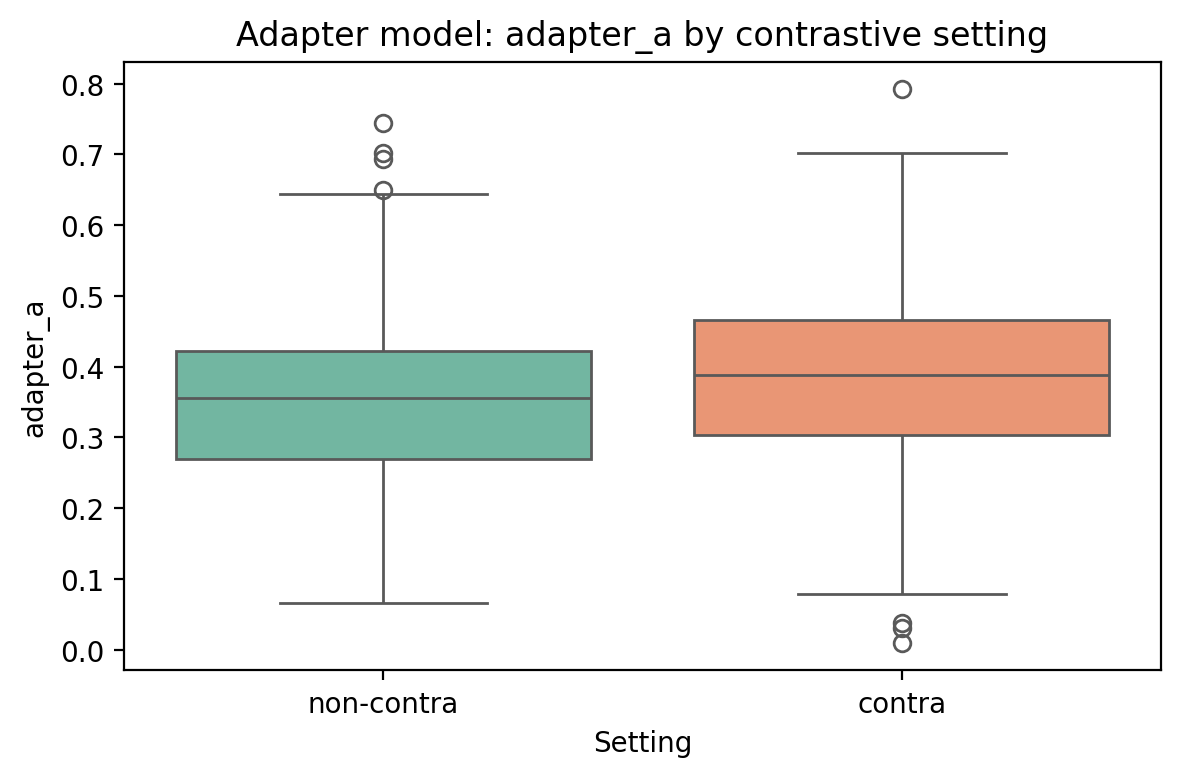

U statistic: 111338.000
p-value: 0.000038
Significant at 0.05: True


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Focus on the adapter model and pick the adapter metric column.
df_adapter = df[df['guidance_model'] == 'adapter'].copy()
metric_col = 'adapter_a' if 'adapter_a' in df_adapter.columns else next(
    (col for col in df_adapter.columns if col.startswith('adapter') and col.endswith('_a')),
    None,
)

if metric_col is None:
    raise ValueError(f"No adapter metric column found. Available columns: {df_adapter.columns.tolist()}")

# Make the contrastive labels easier to read.
df_adapter['contra_label'] = df_adapter['contra'].map({True: 'contra', False: 'non-contra'})

# Boxplot comparison.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')
plt.title(f'Adapter model: {metric_col} by contrastive setting')
plt.xlabel('Setting')
plt.ylabel(metric_col)
plt.tight_layout()
plt.show()

# Statistical significance test.
contra_true = df_adapter.loc[df_adapter['contra'] == True, metric_col].dropna()
contra_false = df_adapter.loc[df_adapter['contra'] == False, metric_col].dropna()

u_stat, p_value = stats.mannwhitneyu(contra_true, contra_false, alternative='two-sided')
print(f'U statistic: {u_stat:.3f}')
print(f'p-value: {p_value:.6f}')
print(f'Significant at 0.05: {p_value < 0.05}')